In [1]:
#0-1　基本設定
!pip install -q catboost==1.2.7
!pip install -q japanize-matplotlib
import japanize_matplotlib

In [2]:
#0-2　基本設定
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool
import shap
import pickle
import gc
import warnings
import time
import os

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#0-3　データ読込

train = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/home-credit-default-risk/加工データ/03FE2/train_FE2.zstd.parquet')
test  = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/Kaggle/home-credit-default-risk/加工データ/03FE2/test_FE2.zstd.parquet')

print(f"train: {train.shape}")
print(f"test:  {test.shape}")
print(f"TARGET分布:\n{train['TARGET'].value_counts(normalize=True)}")

train: (307511, 671)
test:  (48744, 670)
TARGET分布:
TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64


In [6]:
#1-1　データ復元　下準備（ID・ターゲット分離）

TARGET = "TARGET"
ID_COL = "SK_ID_CURR"

y = train[TARGET].values
test_ids = test[ID_COL].values

drop_cols = [TARGET, ID_COL] if ID_COL in train.columns else [TARGET]
X = train.drop(columns=drop_cols)
X_test = test.drop(columns=[c for c in drop_cols if c in test.columns])

# カラム順序を揃える
X_test = X_test[X.columns]
print(f"特徴量数: {X.shape[1]}")

# --- カテゴリ列の特定 ---
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"カテゴリ列数: {len(cat_cols)}")
if cat_cols:
    print(f"例: {cat_cols[:10]}")


# 不要になったデータフレームを削除
if 'train' in locals():
    del train
if 'test' in locals():
    del test
import gc
gc.collect()

特徴量数: 669
カテゴリ列数: 39
例: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


0

In [7]:
#1-2　データ復元　LGBM結果復元

SAVE_DIR = "/content/drive/MyDrive/home_credit_models_gpu"

oof_lgbm_df = pd.read_parquet(os.path.join(SAVE_DIR, "oof_lgbm.parquet"))
oof_lgbm = oof_lgbm_df["oof_lgbm"].values
y = oof_lgbm_df["TARGET"].values

pred_lgbm_df = pd.read_parquet(os.path.join(SAVE_DIR, "pred_lgbm.parquet"))
preds_lgbm = pred_lgbm_df["pred_lgbm"].values
test_ids = pred_lgbm_df["SK_ID_CURR"].values

oof_auc_lgbm = roc_auc_score(y, oof_lgbm)
print(f"LGBM OOF AUC (復元): {oof_auc_lgbm:.5f}")

# ---  重要度データの復元 (LGBM) ---
lgb_imp_raw = pd.read_parquet(os.path.join(SAVE_DIR, "lgbm_importance.parquet"))
lgb_imp = lgb_imp_raw.groupby('feature')['importance'].mean().reset_index()
lgb_imp['LGBM_pct'] = (lgb_imp['importance'] / lgb_imp['importance'].sum()) * 100

LGBM OOF AUC (復元): 0.79271


In [8]:
#1-3　データ復元　CAT結果復元

import glob

# CatBoost GPU版の復元
SAVE_DIR_CAT = "/content/drive/MyDrive/home_credit_models_gpu/home_credit_models_gpu_CAT"

oof_cb_df = pd.read_parquet(os.path.join(SAVE_DIR_CAT, "oof_catboost.parquet"))
oof_cb = oof_cb_df["oof_catboost"].values

pred_cb_df = pd.read_parquet(os.path.join(SAVE_DIR_CAT, "pred_catboost.parquet"))
preds_cb = pred_cb_df["pred_catboost"].values

oof_auc_cb = roc_auc_score(y, oof_cb)
print(f"CatBoost OOF AUC (GPU版復元): {oof_auc_cb:.5f}")

# ---  重要度データの復元 (CatBoost) ---
cat_imp_files = glob.glob(os.path.join(SAVE_DIR_CAT, "catboost_imp_fold*.parquet"))
if not cat_imp_files:
    print(f" {SAVE_DIR_CAT} 内にファイルが見つかりません。")
else:
    # 全Fold分を読み込んで平均化
    cat_imp_list = [pd.read_parquet(f) for f in cat_imp_files]
    cat_imp_raw = pd.concat(cat_imp_list)
    cat_imp = cat_imp_raw.groupby('feature')['importance'].mean().reset_index()

    # 合計を100%に正規化
    cat_imp['CAT_pct'] = (cat_imp['importance'] / cat_imp['importance'].sum()) * 100
    print(f"CatBoost重要度復元完了: {len(cat_imp)} 特徴量")

CatBoost OOF AUC (GPU版復元): 0.79233
CatBoost重要度復元完了: 669 特徴量


In [9]:
#2-1　寄与度確認　アンサンブル（重み調整）

def find_best_weight(oof_a, oof_b, y, steps=101):
    """OOFスコアで最適なブレンド重みをグリッドサーチする。"""
    best_w, best_auc = 0.0, 0.0
    results = []
    for w in np.linspace(0, 1, steps):
        blended = w * oof_a + (1 - w) * oof_b
        auc = roc_auc_score(y, blended)
        results.append((w, auc))
        if auc > best_auc:
            best_w, best_auc = w, auc
    return best_w, best_auc, results

w_lgbm, ensemble_auc, weight_results = find_best_weight(oof_lgbm, oof_cb, y)

print("=" * 60)
print("アンサンブル結果")
print("=" * 60)
print(f"最適重み: LGBM={w_lgbm:.2f}, CatBoost={1 - w_lgbm:.2f}")
print(f"Ensemble OOF AUC: {ensemble_auc:.5f}")
print(f"  (LGBM単体: {oof_auc_lgbm:.5f})")
print(f"  (CatBoost単体: {oof_auc_cb:.5f})")

アンサンブル結果
最適重み: LGBM=0.59, CatBoost=0.41
Ensemble OOF AUC: 0.79411
  (LGBM単体: 0.79271)
  (CatBoost単体: 0.79233)


In [10]:
#2-2　寄与度確認　LGBM,CAT

comparison_df = pd.merge(
        lgb_imp[['feature', 'LGBM_pct']],
        cat_imp[['feature', 'CAT_pct']],
        on='feature',
        how='outer'
    ).fillna(0)

# --- 4. 結果表示 ---
print(f"【モデル精度比較 (AUC)】")
print(f" - LightGBM: {oof_auc_lgbm:.5f}")
print(f" - CatBoost: {oof_auc_cb:.5f}")
print(f" - Ensemble: {ensemble_auc:.5f} (LGBM weight: {w_lgbm:.2f})\n")

# 各モデルのTOP15を抽出
lgb_top15 = comparison_df.sort_values(by='LGBM_pct', ascending=False).head(15)[['feature', 'LGBM_pct']]
cb_top15 = comparison_df.sort_values(by='CAT_pct', ascending=False).head(15)[['feature', 'CAT_pct']]

# 横に並べるための整形
lgb_top15 = lgb_top15.reset_index(drop=True).rename(columns={'feature': 'LGBM Feature', 'LGBM_pct': 'LGBM (%)'})
cb_top15 = cb_top15.reset_index(drop=True).rename(columns={'feature': 'CatBoost Feature', 'CAT_pct': 'CAT (%)'})
side_by_side = pd.concat([lgb_top15, cb_top15], axis=1)

print("■ モデル別重要度 TOP 15")
print(side_by_side.to_markdown(index=False, floatfmt=".2f"))

# --- 共通項目の抽出 ---
common_top = set(lgb_top15['LGBM Feature']) & set(cb_top15['CatBoost Feature'])
print(f"\n■ 両モデル共通の重要項目 ({len(common_top)}件):")
print(f"  {sorted(list(common_top))}")

【モデル精度比較 (AUC)】
 - LightGBM: 0.79271
 - CatBoost: 0.79233
 - Ensemble: 0.79411 (LGBM weight: 0.59)

■ モデル別重要度 TOP 15
| LGBM Feature                    |   LGBM (%) | CatBoost Feature                 |   CAT (%) |
|:--------------------------------|-----------:|:---------------------------------|----------:|
| EXT_SOURCES_GEOM_MEAN           |      11.24 | EXT_SOURCES_MEAN                 |      7.74 |
| EXT_SOURCES_MEAN                |       7.08 | EXT_SOURCES_GEOM_MEAN            |      5.31 |
| ORGANIZATION_TYPE               |       3.59 | CREDIT_ANNUITY_RATIO             |      3.04 |
| EXT_SOURCES_CUSTOM_MEAN         |       2.61 | DIFF_GOODS_CREDIT                |      1.61 |
| EXT_SOURCE_3                    |       2.54 | EXT_SOURCES_BIN_TARGET_RATE      |      1.26 |
| CREDIT_ANNUITY_RATIO            |       2.28 | INS_AMT_PAYMENT_min              |      1.17 |
| EXT_SOURCES_BIN_TARGET_RATE     |       1.66 | GEOM_MEAN_RISK                   |      1.13 |
| EXT_SOURCE_2     

In [11]:
#2-3　寄与度確認　アンサンブル

# 各モデルの重要度にブレンド重みを掛ける
comparison_df['Ensemble_pct'] = (
    comparison_df['LGBM_pct'] * w_lgbm +
    comparison_df['CAT_pct'] * (1 - w_lgbm)
)

# --- 2. 結果の表示 ---

print(f"【アンサンブル寄与度分析】")
print(f" - 最適重み: LGBM={w_lgbm:.2f}, CatBoost={1-w_lgbm:.2f}")
print(f" - Ensemble OOF AUC: {ensemble_auc:.5f}\n")

# アンサンブル寄与度 TOP 20
ensemble_top20 = comparison_df.sort_values(by='Ensemble_pct', ascending=False).head(20)

print(f"■ アンサンブル全体での重要度 TOP 20 (436列中)")
print(ensemble_top20[['feature', 'Ensemble_pct', 'LGBM_pct', 'CAT_pct']].to_markdown(index=False, floatfmt=".2f"))

# --- 3. 考察用の統計 ---

# 片方のモデルでは無視されているが、アンサンブルで浮上した項目の確認
gap_features = comparison_df.assign(gap=abs(comparison_df['LGBM_pct'] - comparison_df['CAT_pct']))
print(f"\n■ モデル間で評価が大きく分かれた項目 (多様性):")
print(gap_features.sort_values(by='gap', ascending=False).head(5)[['feature', 'LGBM_pct', 'CAT_pct']].to_markdown(index=False))

【アンサンブル寄与度分析】
 - 最適重み: LGBM=0.59, CatBoost=0.41
 - Ensemble OOF AUC: 0.79411

■ アンサンブル全体での重要度 TOP 20 (436列中)
| feature                       |   Ensemble_pct |   LGBM_pct |   CAT_pct |
|:------------------------------|---------------:|-----------:|----------:|
| EXT_SOURCES_GEOM_MEAN         |           8.81 |      11.24 |      5.31 |
| EXT_SOURCES_MEAN              |           7.35 |       7.08 |      7.74 |
| CREDIT_ANNUITY_RATIO          |           2.59 |       2.28 |      3.04 |
| ORGANIZATION_TYPE             |           2.16 |       3.59 |      0.12 |
| EXT_SOURCES_CUSTOM_MEAN       |           1.94 |       2.61 |      0.97 |
| EXT_SOURCE_3                  |           1.87 |       2.54 |      0.90 |
| EXT_SOURCES_BIN_TARGET_RATE   |           1.49 |       1.66 |      1.26 |
| DIFF_GOODS_CREDIT             |           1.44 |       1.32 |      1.61 |
| EXT_SOURCE_2                  |           1.23 |       1.43 |      0.94 |
| GEOM_MEAN_RISK                |           1.12 |     

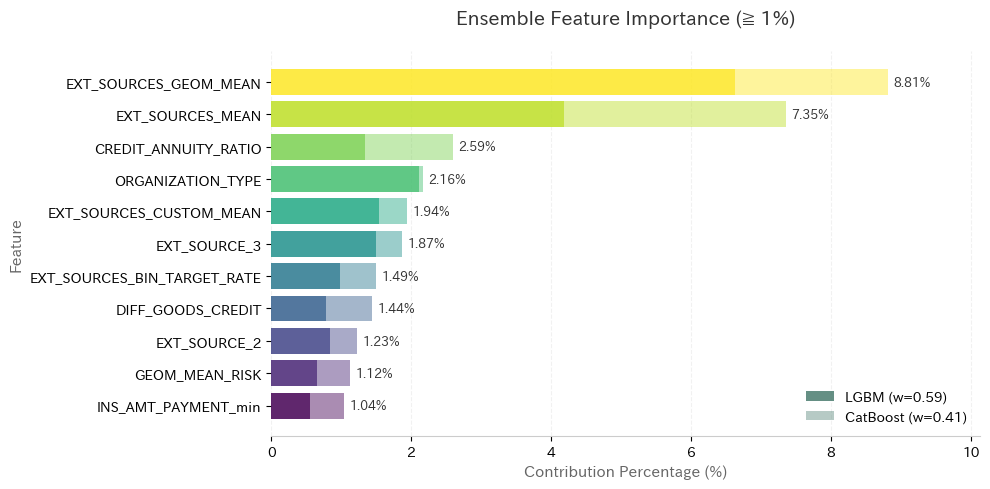

In [12]:
#2-4　寄与度確認　アンサンブル　可視化

plot_df = ensemble_top20.copy()
plot_df = plot_df[plot_df['Ensemble_pct'] >= 1.0]  # 1%以上のみ
plot_df = plot_df.sort_values(by='Ensemble_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)

n = len(plot_df)
cmap = plt.cm.get_cmap('viridis', n)
bar_colors = [cmap(i) for i in range(n)]

# 枠線
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#CCCCCC")

# 各特徴量のアンサンブル寄与度（LGBM + CatBoost）
lgbm_vals = plot_df['LGBM_pct'] * w_lgbm
cat_vals  = plot_df['CAT_pct'] * (1 - w_lgbm)
total_vals = lgbm_vals.values + cat_vals.values

# LGBM部分
bars_lgbm = ax.barh(
    plot_df['feature'], lgbm_vals,
    color=bar_colors, alpha=0.85,
    label=f'LGBM (w={w_lgbm:.2f})'
)

# CatBoost部分（同色で透明度を変えて区別）
bars_cat = ax.barh(
    plot_df['feature'], cat_vals,
    left=lgbm_vals,
    color=bar_colors, alpha=0.45,
    label=f'CatBoost (w={1-w_lgbm:.2f})'
)

# ％ラベルをバー右端に表示
for i, (feature, total) in enumerate(zip(plot_df['feature'], total_vals)):
    ax.text(total + 0.08, i, f'{total:.2f}%',
            va='center', ha='left', fontsize=9, color='#333333', fontweight='bold')

# x軸の余白（ラベルが切れないように）
ax.set_xlim(0, max(total_vals) * 1.15)

# タイトル・ラベル
plt.title('Ensemble Feature Importance (≧ 1%)', fontsize=14, pad=20, color='#333333')
plt.xlabel('Contribution Percentage (%)', fontsize=11, color='#666666')
plt.ylabel('Feature', fontsize=11, color='#666666')

# グリッド
ax.xaxis.grid(True, linestyle='--', which='major', color='#EEEEEE', alpha=0.8)
ax.set_axisbelow(True)

# 凡例（LGBM=濃い、CatBoost=薄い を示す）
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4A7C6F', alpha=0.85, label=f'LGBM (w={w_lgbm:.2f})'),
    Patch(facecolor='#4A7C6F', alpha=0.40, label=f'CatBoost (w={1-w_lgbm:.2f})')
]
ax.legend(handles=legend_elements, frameon=False, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
#3-1　SHAP　設定とモデル復元

# 強制的なメモリ解放
gc.collect()

SAVE_DIR = "/content/drive/MyDrive/home_credit_models_gpu"
SAVE_DIR_CAT = os.path.join(SAVE_DIR, "home_credit_models_gpu_CAT")

# アンサンブル重み (前回の結果より)
w_cb = 1 - w_lgbm

print("モデルをロード中...")

# --- LightGBM (Fold0を代表として使用) ---
# ※保存形式に合わせて読み込み方を調整してください
# 例1: pklの場合
lgb_model_path = os.path.join(SAVE_DIR, "lgbm_fold0.pkl")
if os.path.exists(lgb_model_path):
    with open(lgb_model_path, 'rb') as f:
        model_lgbm = pickle.load(f)
else:
    # 例2: txt形式(Booster)の場合
    lgb_model_path = os.path.join(SAVE_DIR, "lgbm_model_fold0.txt")
    model_lgbm = lgb.Booster(model_file=lgb_model_path)

# --- CatBoost (Fold0を代表として使用) ---
cb_model_path = os.path.join(SAVE_DIR_CAT, "catboost_fold0.cbm")
model_cb = CatBoostClassifier()
model_cb.load_model(cb_model_path)

# 特徴量名の取得 (Xの列順と一致させるため)
if isinstance(model_lgbm, lgb.Booster):
    feature_names = model_lgbm.feature_name()
else:
    feature_names = model_lgbm.feature_name_

print(f"モデルロード完了。特徴量数: {len(feature_names)}")





モデルをロード中...
モデルロード完了。特徴量数: 669


In [14]:
#3-2　SHAP　データサンプリング (メモリ対策)

cat_features_idx = [i for i, f in enumerate(feature_names) if X[f].dtype == 'object' or X[f].dtype.name == 'category']
# メモリ問題避けるため、10,000件をランダムサンプリング
N_SAMPLE = 10000
if len(X) > N_SAMPLE:
    X_sample = X.sample(N_SAMPLE, random_state=42)[feature_names]
else:
    X_sample = X[feature_names]

# CatBoost用のPool作成（サンプリングデータ）
# カテゴリカル変数のインデックスを取得（もしあれば）
for idx in cat_features_idx:
    col = X_sample.columns[idx]
    X_sample[col] = X_sample[col].cat.add_categories("missing").fillna("missing")

cat_pool_sample = Pool(X_sample, cat_features=cat_features_idx)

print(f"SHAP計算用サンプリング完了: {X_sample.shape}")

SHAP計算用サンプリング完了: (10000, 669)


In [15]:
#3-3　SHAP　SHAP値の計算と加重平均

print("SHAP値を計算中...")

# --- 3-1. LGBM SHAP  ---
explainer_lgb = shap.TreeExplainer(model_lgbm)
# shap_values[1]が正例(TARGET=1)のSHAP値
sv = explainer_lgb.shap_values(X_sample)
shap_values_lgb = sv[1] if isinstance(sv, list) else sv


# --- 3-2. CatBoost SHAP (GPU互換性注意、CPUで計算) ---
print("CatBoost SHAP計算中...")
try:
    # CatBoostのget_feature_importanceでShapValuesを取得
    # これによりサンプリングデータに対するSHAP値が返る
    shap_values_cb_raw = model_cb.get_feature_importance(
        cat_pool_sample,
        type='ShapValues'
    )
    # 最後の列はExpected Value（バイアス項）なので除く
    shap_values_cb = shap_values_cb_raw[:, :-1]

except Exception as e:
    print(f" CatBoostのSHAP計算でエラーが発生しました: {e}")
    print("アンサンブルSHAPの作成を断念し、LGBM単体のSHAPを表示します。")
    shap_values_ensemble = shap_values_lgb
    is_ensemble_shap = False
else:
    # --- 3-3. 加重平均 (アンサンブルSHAP) ---
    print("アンサンブルSHAPを合成中...")
    shap_values_ensemble = (shap_values_lgb * w_lgbm) + (shap_values_cb * w_cb)
    is_ensemble_shap = True

print("SHAP計算完了")


SHAP値を計算中...
CatBoost SHAP計算中...
アンサンブルSHAPを合成中...
SHAP計算完了



--- Ensemble SHAP Summary Plot ---


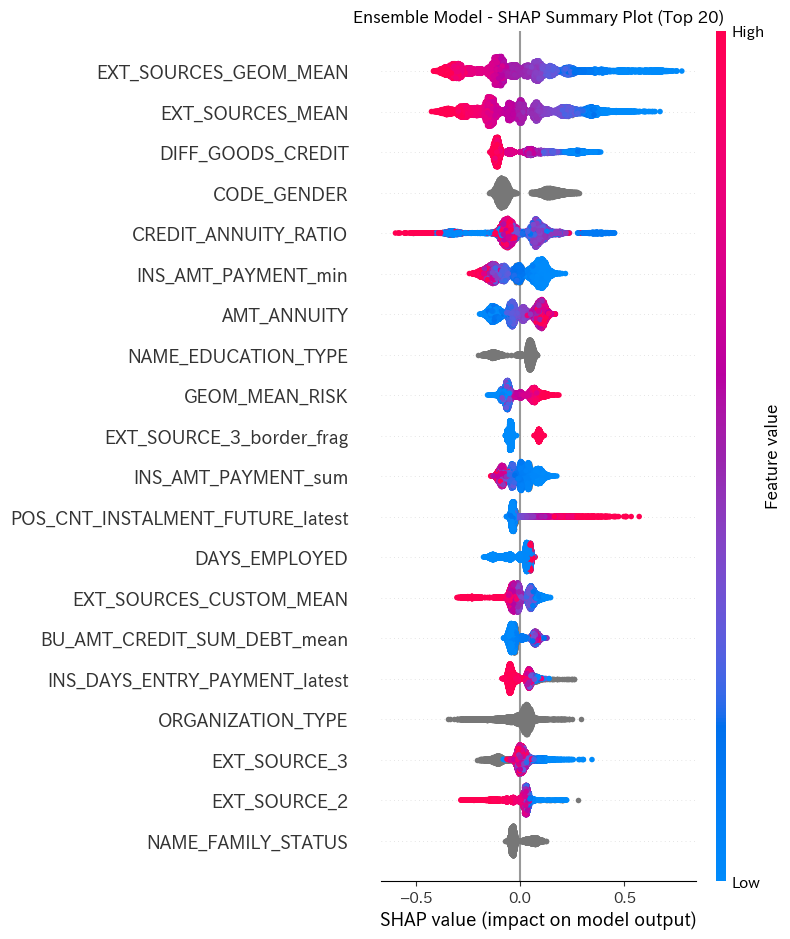


--- Ensemble SHAP Dependence Plot: EXT_SOURCES_GEOM_MEAN ---


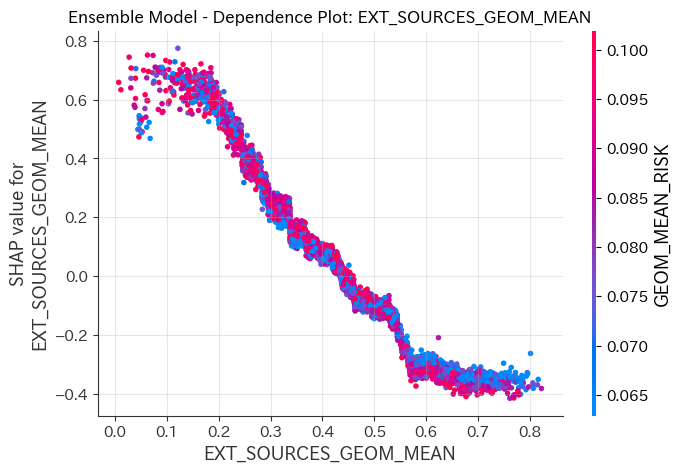


--- SHAP Dependence Plot: EXT_SOURCES_MEAN ---


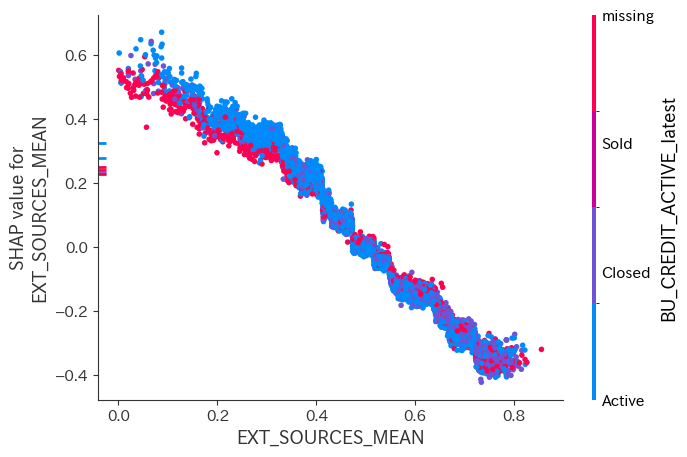

In [16]:
#3-4　SHAP　可視化1 (Summary Plot & Dependence Plot)

title_prefix = "Ensemble" if is_ensemble_shap else "LightGBM"

print(f"\n--- {title_prefix} SHAP Summary Plot ---")
# モデルが「貸し倒れ（TARGET=1）」と判断するのに効いている変数TOP20
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_ensemble,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title(f"{title_prefix} Model - SHAP Summary Plot (Top 20)")
plt.tight_layout()
plt.show()

# --- Dependence Plot (最も重要な特徴量について) ---
# Summary Plotで1位だった特徴量を自動取得
top_feature = feature_names[np.abs(shap_values_ensemble).mean(0).argmax()]

print(f"\n--- {title_prefix} SHAP Dependence Plot: {top_feature} ---")
# 特徴量の値（横軸）とSHAP値（縦軸）の関係
# 相互作用がある変数を自動で色付け
shap.dependence_plot(
    top_feature,
    shap_values_ensemble,
    X_sample,
    feature_names=feature_names,
    show=False
)
plt.title(f"{title_prefix} Model - Dependence Plot: {top_feature}")
plt.grid(True, alpha=0.3)
plt.show()

# EXT_SOURCE
target_feat = 'EXT_SOURCES_MEAN'
if target_feat in feature_names:
     print(f"\n--- SHAP Dependence Plot: {target_feat} ---")
     shap.dependence_plot(target_feat, shap_values_ensemble, X_sample, show=False)
     plt.show()



*   Summary Plot  
寄与度5％以上となるEXT_SOURCES_GEOM_MEAN(幾何平均)とEXT_SOURCES_MEAN(平均)では概ね同程度の傾向にあるが、幾何平均の方が低スコアの密度が太く、高スコアの裾が長いことから、1つでも低スコアがあればリスク信号として拾いやすい傾向があった。
*   SHAP Dependence Plot(幾何平均、平均)  
幾何平均ではSHAPの範囲がおよそ-0.4～+0.8であり、スコアが高くなるほどデフォルトリスクが低下。特に0.55あたりで急激に下がっている。一方で平均では-0.4～+0.6の範囲で緩やかな減少となっている。このため、単体の指標としては幾何平均の方がより3種のスコアの特徴をより捉えられていると考えられる。  
また、相互作用としては幾何平均とGEOM_RISK_MEAN(業種×職種×収入タイプのデフォルト率の幾何平均)の組み合わせとしてみると、高スコアでもGEOM_RISK_MEANの値は高いものが多く、外部スコアが高くても業種・職種由来のリスクが残るケースを捉えており、外部スコアだけでは拾えないリスク要因を補完している。一方で平均とBU_CREDIT_ACTIVE_latest(直近のローン状況)の組み合わせではSold（債権売却）またはmissing（履歴なし）の場合と傾向が一致しており、目検でも判断しやすい。CATでの寄与度が幾何平均より高いのもこの点による差だと思われる。




--- Ensemble SHAP Analysis: DIFF_GOODS_CREDIT ---


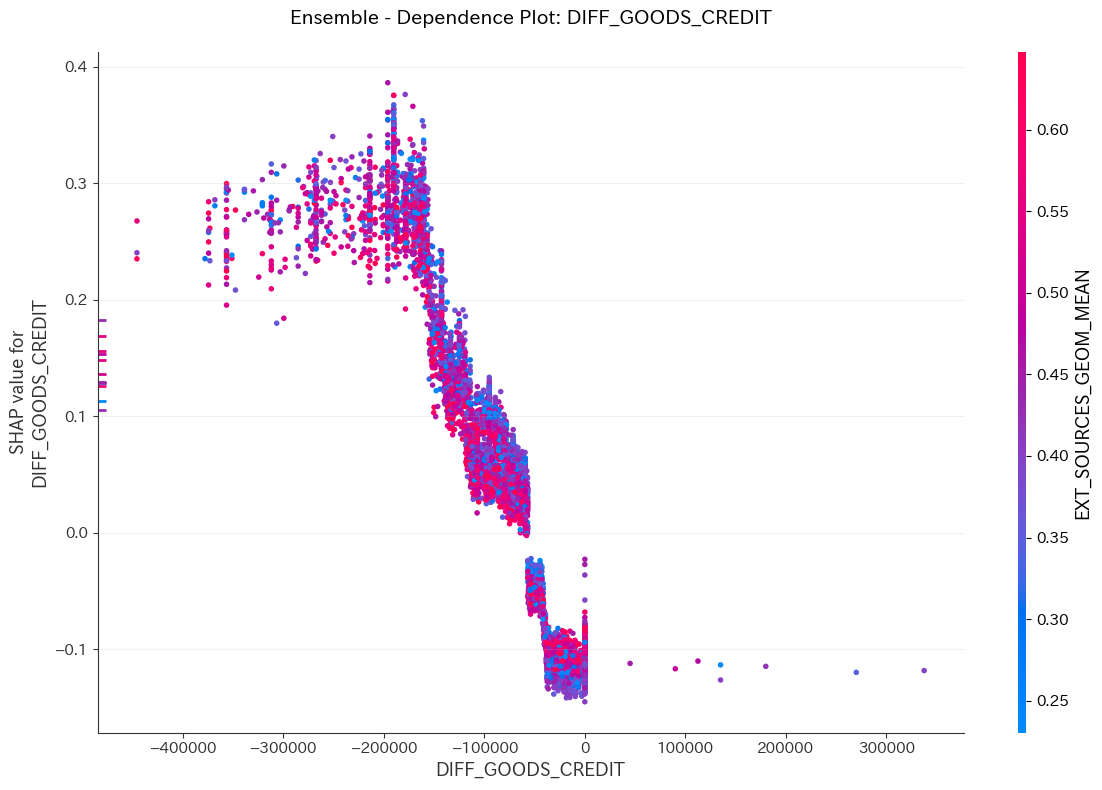


--- Ensemble SHAP Analysis: ORGANIZATION_TYPE ---


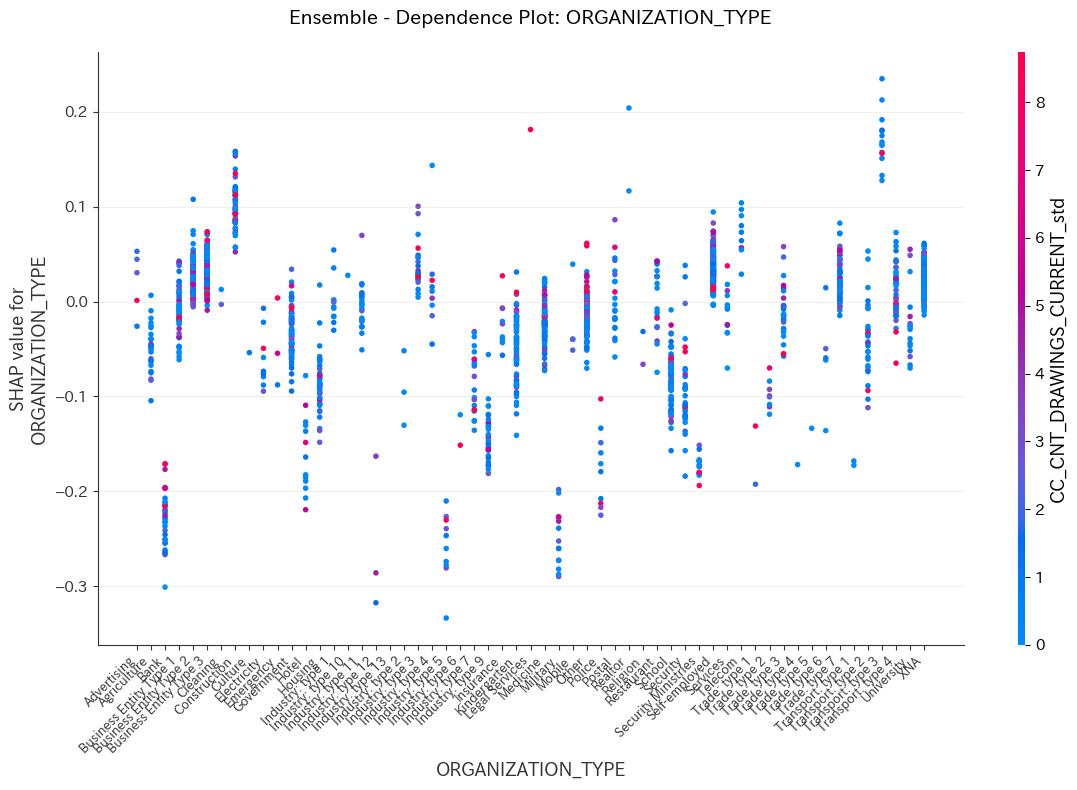

In [17]:
#3-5　SHAP　可視化2 (DIFF_GOODS_CREDIT、ORGANIZATION_TYPE)

target_features = ['DIFF_GOODS_CREDIT', 'ORGANIZATION_TYPE']

for feat in target_features:
    if feat in feature_names:
        print(f"\n--- {title_prefix} SHAP Analysis: {feat} ---")

        # 描画サイズを少し大きめにして視認性を確保
        fig, ax = plt.subplots(figsize=(12,8))

        # 標準の dependence_plot を実行
        # ax=ax を指定することで、matplotlibの細かい調整が可能になります
        shap.dependence_plot(
            feat,
            shap_values_ensemble,
            X_sample,
            feature_names=feature_names,
            show=False,
            ax=ax
        )

        # タイトルの追加
        ax.set_title(f"{title_prefix} - Dependence Plot: {feat}", fontsize=14, pad=20)

        # カテゴリ変数の場合、X軸のラベル（業種名など）を回転させて読みやすくする
        is_categorical = (X_sample[feat].dtype == 'object' or X_sample[feat].dtype.name == 'category')
        if is_categorical:
            plt.xticks(rotation=45, ha='right', fontsize=9)
            # 業種が多いので、目盛りを間引かずに全部表示する設定
            ax.set_xticks(range(len(X_sample[feat].unique())))

        plt.grid(True, alpha=0.2, axis='y')
        plt.tight_layout()
        plt.show()



*   DIFF_GOODS_CREDIT(商品価格-借入額)  
差額が-200000以上ではSHAP0.2～0.4の範囲でばらつき、差額が小さくなるにつれSHAPは下がる傾向にある。-50000と-150000のあたりで大きく分布が変わり、差額0ではSHAPがややばらつく。全体的には-0.15～+0.4の範囲で推移し、商品価格と借入額の差額が大きくなるほどSHAP値が高くなる傾向にある。  
商品の本体価格以外の付随費用の可能性もあるが、差額が大きいものは商品購入自体が目的ではない可能性も考えられうる。
*   ORGANIZATION_TYPE(職業)  
ばらつきの大きい業種もあるが、概ね業種別にSHAP値が固まる傾向あり、ただサンプル数に偏りがあり、過学習によってノイズとなっている可能性を否定しきれない。次回以降はユニーク値別のサンプル数によっては削除か、加工を検討すべき情報だと思われる。



In [18]:
#4-1　混同行列と閾値の最適化(F1:Macro平均)

y_prob = oof_lgbm * w_lgbm + oof_cb * (1 - w_lgbm)

from sklearn.metrics import (
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score
)

def business_impact_report(y_true, y_prob, threshold, amounts):
    """
    amounts: 各サンプルに対応する融資金額（または損失予測額）の配列
    """
    y_pred = (y_prob >= threshold).astype(int)
    # ※関数内でy_probを再計算すると外部のy_probとズレる可能性があるため、
    # 基本的には引数で受け取ったy_probをそのまま使うのが安全です。

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # 金額の計算
    total_saved_amount = amounts[(y_pred == 1) & (y_true == 1)].sum()
    total_missed_amount = amounts[(y_pred == 0) & (y_true == 1)].sum()

    avg_saved = total_saved_amount / tp if tp > 0 else 0
    avg_missed = total_missed_amount / fn if fn > 0 else 0

    weighted_recall = total_saved_amount / (total_saved_amount + total_missed_amount) if (total_saved_amount + total_missed_amount) > 0 else 0

    # 統計量の計算
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    print("=" * 85)
    print(f" 混同行列 最適化 (Threshold: {threshold:.4f}, Macro-F1: {(f[0]+f[1])/2:.4f})")
    print("=" * 85)
    # --- ここに追加 ---
    print(f" 合計検知額: {total_saved_amount:,.0f} | 合計見逃し額: {total_missed_amount:,.0f}")
    print(f" 平均検知額(算出): {avg_saved:.1f} | 平均見逃し額(算出): {avg_missed:.1f}")
    # ------------------
    print(f" 金額荷重Recall: {weighted_recall:.4f} | PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f}")
    print("-" * 85)

    total = tp + fp + tn + fn
    # クラス1（デフォルト）
    print(f" クラス1(ﾃﾞﾌｫﾙﾄ) | Precision: {p[1]:.4f} | Recall: {r[1]:.4f} | F1: {f[1]:.4f}")
    print(f" 【デフォルト判定】: {tp+fp:,}件 / 全体{total:,}件中 ({(tp+fp)/total*100:.2f}%)")
    print("-" * 85)

    # クラス0（正常）
    print(f" クラス0(正常)   | Precision: {p[0]:.4f} | Recall: {r[0]:.4f} | F1: {f[0]:.4f}")
    print(f" 【正常判定】: {tn+fn:,}件 / 全体{total:,}件中 ({(tn+fn)/total*100:.2f}%)")
    print("=" * 85)

# 1. 閾値の候補を作成
thresholds = np.linspace(0, 1, 101) # 0から1まで0.01刻みで試す
macro_f1_scores = []

# 2. 各閾値で「Macro平均 F1」を計算
for thr in thresholds:
    y_pred_temp = (y_prob >= thr).astype(int)
    # average='macro' を指定することで、0と1のF1の平均を計算
    score = f1_score(y, y_pred_temp, average='macro')
    macro_f1_scores.append(score)

# 3. 最大値となる閾値を特定
best_idx = np.argmax(macro_f1_scores)
best_threshold_macro = thresholds[best_idx]
best_macro_f1 = macro_f1_scores[best_idx]

print(f"Macro F1最大化 閾値: {best_threshold_macro:.4f}")
print(f"その時の最大Macro F1: {best_macro_f1:.4f}")

# 4. レポートを表示
business_impact_report(y, y_prob, best_threshold_macro, amounts=X['AMT_CREDIT'].values)

Macro F1最大化 閾値: 0.3000
その時の最大Macro F1: 0.6383
 混同行列 最適化 (Threshold: 0.3000, Macro-F1: 0.6383)
 合計検知額: 4,574,398,550 | 合計見逃し額: 9,272,453,400
 平均検知額(算出): 507815.1 | 平均見逃し額(算出): 586233.4
 金額荷重Recall: 0.3304 | PR-AUC: 0.2914 | ROC-AUC: 0.7941
-------------------------------------------------------------------------------------
 クラス1(ﾃﾞﾌｫﾙﾄ) | Precision: 0.3182 | Recall: 0.3629 | F1: 0.3391
 【デフォルト判定】: 28,306件 / 全体307,511件中 (9.20%)
-------------------------------------------------------------------------------------
 クラス0(正常)   | Precision: 0.9433 | Recall: 0.9317 | F1: 0.9375
 【正常判定】: 279,205件 / 全体307,511件中 (90.80%)


F1スコアで最適化させた結果、非デフォルトのプレシジョン及びリコールは良好であったが、デフォルト判定の的中率は低く3割程度となった。  
実運用においては、正常判定はある程度信頼できるものの、デフォルト判定では自動化とは程遠いスコアであると判断せざるを得ない。  
そのため全自動化は不可能であるが、デフォルト判定された9.2%を人間が二次審査する形式であれば申請全体の9割を自動判定が可能となる。

In [19]:
#4-2　混同行列と閾値の最適化(正常判定自動化)

from sklearn.metrics import precision_recall_fscore_support

for target in [0.95,0.96,0.97,0.98,0.99]:
    best_thr, best_auto = 0, 0
    for thr in np.linspace(0.01, 0.99, 99):
        y_pred = (y_prob >= thr).astype(int)
        normal_mask = (y_pred == 0)
        if normal_mask.sum() == 0:
            continue
        normal_prec = (y[normal_mask] == 0).mean()
        if normal_prec >= target:
            auto_rate = normal_mask.mean()
            if auto_rate > best_auto:
                best_thr, best_auto = thr, auto_rate
    print(f"正常Precision≥{target:.0%} → 自動承認: {best_auto*100:.1f}%  閾値: {best_thr:.4f}")

for target in [0.95, 0.96, 0.97, 0.98, 0.99]:
    best_thr, best_auto = 0, 0
    for thr in np.linspace(0.01, 0.99, 99):
        y_pred = (y_prob >= thr).astype(int)
        normal_mask = (y_pred == 0)
        if normal_mask.sum() == 0:
            continue
        normal_prec = (y[normal_mask] == 0).mean()
        if normal_prec >= target:
            auto_rate = normal_mask.mean()
            if auto_rate > best_auto:
                best_thr, best_auto = thr, auto_rate
    print(f"\n{'▼'*5} 正常Precision≥{target:.0%} {'▼'*5}")
    business_impact_report(y, y_prob, best_thr, amounts=X['AMT_CREDIT'].values)


正常Precision≥95% → 自動承認: 86.1%  閾値: 0.2400
正常Precision≥96% → 自動承認: 76.9%  閾値: 0.1700
正常Precision≥97% → 自動承認: 62.6%  閾値: 0.1100
正常Precision≥98% → 自動承認: 39.4%  閾値: 0.0600
正常Precision≥99% → 自動承認: 15.6%  閾値: 0.0300

▼▼▼▼▼ 正常Precision≥95% ▼▼▼▼▼
 混同行列 最適化 (Threshold: 0.2400, Macro-F1: 0.6324)
 合計検知額: 5,982,699,708 | 合計見逃し額: 7,864,152,242
 平均検知額(算出): 513624.6 | 平均見逃し額(算出): 596809.0
 金額荷重Recall: 0.4321 | PR-AUC: 0.2914 | ROC-AUC: 0.7941
-------------------------------------------------------------------------------------
 クラス1(ﾃﾞﾌｫﾙﾄ) | Precision: 0.2733 | Recall: 0.4692 | F1: 0.3454
 【デフォルト判定】: 42,617件 / 全体307,511件中 (13.86%)
-------------------------------------------------------------------------------------
 クラス0(正常)   | Precision: 0.9503 | Recall: 0.8904 | F1: 0.9194
 【正常判定】: 264,894件 / 全体307,511件中 (86.14%)

▼▼▼▼▼ 正常Precision≥96% ▼▼▼▼▼
 混同行列 最適化 (Threshold: 0.1700, Macro-F1: 0.5994)
 合計検知額: 8,114,875,160 | 合計見逃し額: 5,731,976,790
 平均検知額(算出): 524250.6 | 平均見逃し額(算出): 613308.0
 金額荷重Recall: 0.5860

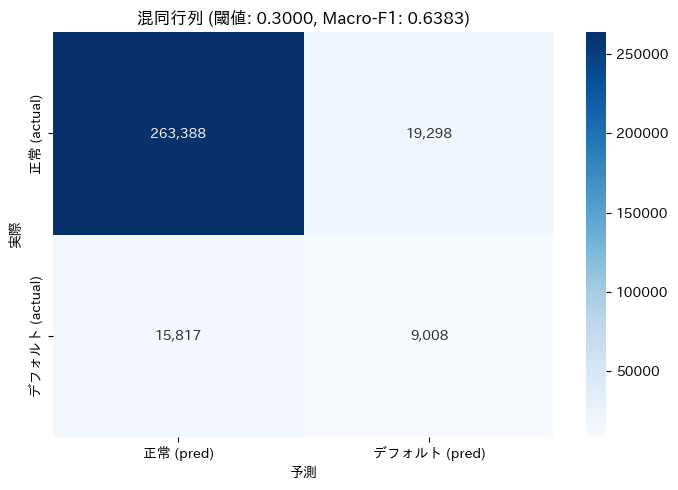

In [20]:
#4-3　混同行列ヒートマップ（F1最適閾値）

from sklearn.metrics import confusion_matrix

y_pred_best = (y_prob >= best_threshold_macro).astype(int)
cm = confusion_matrix(y, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['正常 (pred)', 'デフォルト (pred)'],
            yticklabels=['正常 (actual)', 'デフォルト (actual)'],
            ax=ax)
ax.set_title(f'混同行列 (閾値: {best_threshold_macro:.4f}, Macro-F1: {best_macro_f1:.4f})')
ax.set_ylabel('実際')
ax.set_xlabel('予測')
plt.tight_layout()
plt.show()

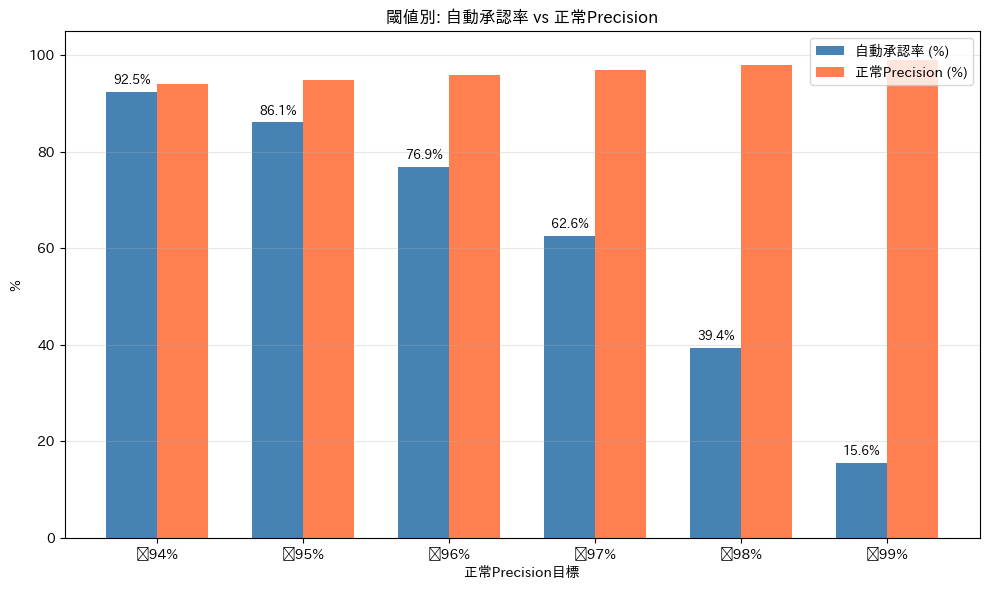


■ 閾値別サマリ
| 正常Precision目標   |   最適閾値 | 自動承認率   |
|:--------------------|-----------:|:-------------|
| ≥94%                |       0.33 | 92.5%        |
| ≥95%                |       0.24 | 86.1%        |
| ≥96%                |       0.17 | 76.9%        |
| ≥97%                |       0.11 | 62.6%        |
| ≥98%                |       0.06 | 39.4%        |
| ≥99%                |       0.03 | 15.6%        |


In [21]:
#4-4　閾値別 自動化率・Precision比較

targets = [0.94, 0.95, 0.96, 0.97, 0.98, 0.99]
auto_rates = []
precisions = []
best_thresholds = []

for target in targets:
    best_thr, best_auto = 0, 0
    for thr in np.linspace(0.01, 0.99, 99):
        y_pred = (y_prob >= thr).astype(int)
        normal_mask = (y_pred == 0)
        if normal_mask.sum() == 0:
            continue
        normal_prec = (y[normal_mask] == 0).mean()
        if normal_prec >= target:
            auto_rate = normal_mask.mean()
            if auto_rate > best_auto:
                best_thr, best_auto = thr, auto_rate
    auto_rates.append(best_auto * 100)
    precisions.append(target * 100)
    best_thresholds.append(best_thr)

x = np.arange(len(targets))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))

bars1 = ax1.bar(x - width/2, auto_rates, width, label='自動承認率 (%)', color='steelblue')
bars2 = ax1.bar(x + width/2, precisions, width, label='正常Precision (%)', color='coral')

ax1.set_xlabel('正常Precision目標')
ax1.set_ylabel('%')
ax1.set_title('閾値別: 自動承認率 vs 正常Precision')
ax1.set_xticks(x)
ax1.set_xticklabels([f'≥{t:.0%}' for t in targets])
ax1.set_ylim(0, 105)
ax1.legend(loc='upper right')

# バーの上に数値を表示
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# テーブルも出力
print("\n■ 閾値別サマリ")
summary = pd.DataFrame({
    '正常Precision目標': [f'≥{t:.0%}' for t in targets],
    '最適閾値': [f'{t:.4f}' for t in best_thresholds],
    '自動承認率': [f'{r:.1f}%' for r in auto_rates],
})
print(summary.to_markdown(index=False))

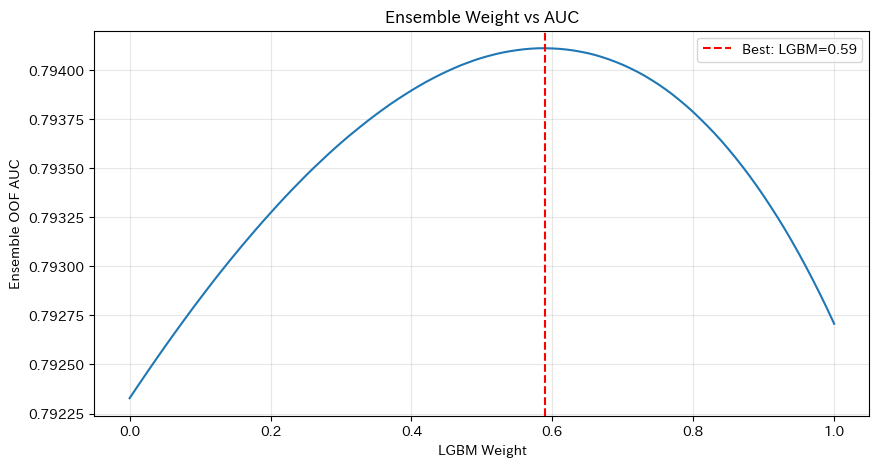

In [22]:
#5-1　アンサンブル配分AUC　可視化
weights, aucs = zip(*weight_results)
plt.figure(figsize=(10, 5))
plt.plot(weights, aucs)
plt.xlabel("LGBM Weight")
plt.ylabel("Ensemble OOF AUC")
plt.title("Ensemble Weight vs AUC")
plt.axvline(x=w_lgbm, color='r', linestyle='--', label=f'Best: LGBM={w_lgbm:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

緩やかな弧の形状であり、LGBM=0.59付近にピークがある。0.4〜0.7の広い範囲でAUCが安定しているため、重み設定に対してロバストであると考えられる。

【モデル】  
今回のデータでは細分化されているカラムがあり、LGBM単体ではやや過学習に陥りやすい傾向にあった。その点はCATとアンサンブルさせることでバランスの取れた構成になったことが寄与度や、アンサンブル閾値グラフから読み取れる。  
また、寄与度からは追加した特徴量が多くランクインしたがEXT系が支配的な点は変わらず、有効なものを作る難しさを実感した。  

【Precision-Recall】  
正常判定の自動化において、閾値を厳しくすれば正常判定件数が少なく、緩くすれば精度が低くなり、自動承認と精度はトレードオフの関係にある。今回のケースであれば精度99%は15%程度しか自動承認できない上に、デフォルトのプレシジョンは9%であるため、デフォルト判定された申請で人間による2次審査を行うとすると量・質ともに負担が大きい。  
一方で95%ラインであれば業務量の86%を自動化できるが、自動承認した中の5%がデフォルトする。  
この点については、企業の抱える与信判定のノウハウやキャパシティ、人的コストとのバランスを見て決定すべき事項と考えられる。  
当該コンペにおいては通貨が不明であるため金額ベースの判断は困難だが、自動承認率と精度のバランスから0.94〜0.97あたりが現実的な選択肢だと思われる。